<p align="center">
  <a href="https://github.com/wavekat/wavekat-lab">
    <img src="https://github.com/wavekat/wavekat-brand/raw/main/assets/banners/wavekat-lab-narrow.svg" alt="WaveKat Lab">
  </a>
</p>

# Smart-Turn — train (baseline)

Baseline run: pinned `pos_weight`, F1-best threshold sweep, **no
augmentation**. This is the reference number against which every other
`02_<letter>_*` variant is compared.

The model, dataset, and training helpers live in
[`smart_turn.py`](./smart_turn.py); this notebook is the config + run
harness for the baseline. Variants
(`02_b_train_specaugment.ipynb`, ...) reuse the same module and only
change the config block + dataset construction.

Pipeline:

1. Reuse the loader from `01_load_export.ipynb` to pick up Parquet shards.
2. Build the Whisper-encoder + attention-pool + classifier from `smart_turn.build_model`.
3. Wrap each split in `SmartTurnDataset` (no augment for baseline).
4. Train with HF `Trainer`, validating once per epoch with the
   threshold-sweep `compute_metrics`.
5. Pick the F1-best threshold on the val split, plot PR curve, save the
   HF checkpoint + `threshold.json` into `CHECKPOINT_DIR` for
   `03_compare.ipynb` to pick up alongside the other variants.

**Compute.** CUDA is the happy path. Apple Silicon MPS works as a
slower alternative (fp32 only). On pure CPU the training step is too
slow to finish.

## Configure

`RUN_NAME` is the subdir under `checkpoints/<dataset>/` where this
variant's HF checkpoint + `threshold.json` lands. Keep it stable per
variant so `03_compare.ipynb` (and the experiments table in `README.md`)
can refer to it by name.

`WARM_START_FROM` lets a new run continue from a previous checkpoint
instead of the raw Whisper encoder. Typical use: a fresh dataset
snapshot (e.g. `0502`) trains on top of the prior snapshot's baseline
(`0501/baseline`) so the classifier head doesn't reset every time the
data grows. Set to `None` for a cold start from `BASE_MODEL`.

In [25]:
import os
from pathlib import Path

DATASET_NAME = "smart-turn-zh-0502"
RUN_NAME = "baseline"  # change per variant; matches the file name suffix.

# Optional: continue from a previously trained checkpoint instead of
# the raw Whisper encoder. Path is relative to this notebook (or
# absolute). Set to None for a cold start.
# Example: warm-start 0502 from 0501's baseline.
WARM_START_FROM: str | None = "../../checkpoints/smart-turn-zh-0501/baseline"

EXPORT_DIR = Path(f"../../datasets/{DATASET_NAME}").resolve()
CHECKPOINT_DIR = Path(f"../../checkpoints/{DATASET_NAME}/{RUN_NAME}").resolve()
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

WARM_START_DIR = Path(WARM_START_FROM).resolve() if WARM_START_FROM else None
if WARM_START_DIR is not None:
    assert WARM_START_DIR.exists(), (
        f"WARM_START_FROM not found: {WARM_START_DIR}. Train that run first or set "
        f"WARM_START_FROM = None to cold-start from BASE_MODEL."
    )
    assert WARM_START_DIR.resolve() != CHECKPOINT_DIR.resolve(), (
        "WARM_START_FROM points at the current run's CHECKPOINT_DIR — that would "
        "overwrite the warm-start source mid-training."
    )

BASE_MODEL = "openai/whisper-tiny"
TARGET_SR = 16_000
CHUNK_LENGTH = 8  # seconds — model input cap, matches upstream

# Hyperparameters — tuned for ~1k-sample exports. Upstream defaults
# (batch 384, 4 epochs) assume 270k samples; with ~1k we drop the batch
# and run more epochs so each sample is seen enough times.
BATCH_SIZE = 16
GRAD_ACCUM = 1
EVAL_BATCH_SIZE = 32
EPOCHS = 8
LR = 5e-5
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01

assert EXPORT_DIR.exists(), (
    f"{EXPORT_DIR.name} not found. Re-run `wk exports adapt smart-turn --out {EXPORT_DIR}` "
    f"or override DATASET_NAME above."
)
print("dataset      :", DATASET_NAME)
print("run name     :", RUN_NAME)
print("export dir   :", EXPORT_DIR.name)
print("checkpoint   :", CHECKPOINT_DIR.relative_to(CHECKPOINT_DIR.parent.parent))
print("base model   :", BASE_MODEL)
print(
    "warm start   :",
    WARM_START_DIR.relative_to(CHECKPOINT_DIR.parent.parent) if WARM_START_DIR else "(cold start from base model)",
)
print("epochs/batch :", f"{EPOCHS} / {BATCH_SIZE} (x {GRAD_ACCUM} accum)")
print("✅ config ready")

dataset      : smart-turn-zh-0502
run name     : baseline
export dir   : smart-turn-zh-0502
checkpoint   : smart-turn-zh-0502/baseline
base model   : openai/whisper-tiny
warm start   : smart-turn-zh-0501/baseline
epochs/batch : 8 / 16 (x 1 accum)
✅ config ready


## Load dataset

Same loader as `01_load_export.ipynb`. Keeping the block stable means a
new export drops in without touching the training notebook.

In [26]:
from datasets import load_dataset, Audio, disable_progress_bars

disable_progress_bars()

data_files = {
    split: str(EXPORT_DIR / f"{split}.parquet")
    for split in ("train", "validation", "test")
    if (EXPORT_DIR / f"{split}.parquet").exists()
}
assert "train" in data_files, "train.parquet missing — adapt step did not produce it."

ds = load_dataset("parquet", data_files=data_files)
ds = ds.cast_column("audio", Audio(sampling_rate=TARGET_SR))
print(ds)
print("✅ dataset loaded")

DatasetDict({
    train: Dataset({
        features: ['annotation_id', 'audio', 'endpoint_bool', 'language', 'clip_sha256', 'source_file_id', 'source_file_sha256', 'labeller_id', 'clip_duration_sec'],
        num_rows: 1470
    })
    validation: Dataset({
        features: ['annotation_id', 'audio', 'endpoint_bool', 'language', 'clip_sha256', 'source_file_id', 'source_file_sha256', 'labeller_id', 'clip_duration_sec'],
        num_rows: 185
    })
    test: Dataset({
        features: ['annotation_id', 'audio', 'endpoint_bool', 'language', 'clip_sha256', 'source_file_id', 'source_file_sha256', 'labeller_id', 'clip_duration_sec'],
        num_rows: 181
    })
})
✅ dataset loaded


## Model

`SmartTurnModel` (Whisper Tiny encoder → attention pooling → 2-layer
classifier) is defined in `smart_turn.py`. `build_model` constructs it
and loads the pretrained encoder weights, leaving the head fresh.

If `WARM_START_FROM` is set, we instead load the full prior checkpoint
(encoder + pool + classifier) via `SmartTurnModel.from_pretrained`, so
training continues from the previous run's head rather than reinitialising
it. `pos_weight` is always re-pinned from the **current** train split's
label distribution — class balance can shift between snapshots.

In [27]:
import torch
from smart_turn import SmartTurnModel, build_model, pick_device, pos_weight_from_labels

device = pick_device()
print("device:", device)
if device.type == "cuda":
    print("gpu   :", torch.cuda.get_device_name(0))
    print("vram  :", f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

if WARM_START_DIR is not None:
    model = SmartTurnModel.from_pretrained(str(WARM_START_DIR))
    init_source = f"warm-start: {WARM_START_DIR.relative_to(CHECKPOINT_DIR.parent.parent)}"
else:
    model = build_model(BASE_MODEL)
    init_source = f"cold-start: {BASE_MODEL}"

pos_w = pos_weight_from_labels(ds["train"]["endpoint_bool"])
model.set_pos_weight(pos_w)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"init from    : {init_source}")
print(f"params       : {total:,} total, {trainable:,} trainable")
print(f"pos_weight   : {pos_w:.3f}")
print("✅ model initialised")

device: mps


Loading weights:   0%|          | 0/80 [00:00<?, ?it/s]

init from    : warm-start: smart-turn-zh-0501/baseline
params       : 8,000,386 total, 8,000,386 trainable
pos_weight   : 0.897
✅ model initialised


## Feature extraction

`SmartTurnDataset` (in `smart_turn.py`) computes mel spectrograms on
the fly. `augment` is a callable applied per-sample to the train split
only; baseline passes `None` so no masking happens.

In [28]:
from transformers import WhisperFeatureExtractor
from smart_turn import SmartTurnDataset

feature_extractor = WhisperFeatureExtractor(chunk_length=CHUNK_LENGTH)

train_dataset = SmartTurnDataset(
    ds["train"], feature_extractor, TARGET_SR, CHUNK_LENGTH, augment=None,
)
eval_dataset = SmartTurnDataset(
    ds.get("validation", ds["train"]), feature_extractor, TARGET_SR, CHUNK_LENGTH, augment=None,
)

print(f"train: {len(train_dataset):,}  (augment=off)")
print(f"eval : {len(eval_dataset):,}  (augment=off)")

# Sanity-check one sample so a downstream shape mismatch fails here, not 30 min into training.
sample0 = train_dataset[0]
print("sample input_features:", tuple(sample0["input_features"].shape))
print("sample label         :", float(sample0["labels"]))
print("✅ feature extractor + datasets ready")

train: 1,470  (augment=off)
eval : 185  (augment=off)
sample input_features: (80, 800)
sample label         : 1.0
✅ feature extractor + datasets ready


## Train

Eval/save per epoch — with ~60 train steps per epoch the per-step
strategy is too noisy to drive `load_best_model_at_end`. `f1` is the
selection metric since label balance is uneven across snapshots.

In [29]:
from transformers import Trainer, TrainingArguments
from smart_turn import compute_metrics_with_threshold

use_cuda = torch.cuda.is_available()
training_args = TrainingArguments(
    output_dir=str(CHECKPOINT_DIR),
    run_name=f"{DATASET_NAME}-{RUN_NAME}",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=10,
    # On macOS (MPS / CPU) soundfile can't survive a DataLoader worker fork
    # — keep workers in-process. CUDA boxes can use 2 for throughput.
    dataloader_num_workers=2 if use_cuda else 0,
    dataloader_pin_memory=use_cuda,
    bf16=use_cuda and torch.cuda.is_bf16_supported(),
    fp16=use_cuda and not torch.cuda.is_bf16_supported(),
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="wandb" if os.environ.get("WANDB_API_KEY") else "none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics_with_threshold,
)

print("effective batch:", BATCH_SIZE * GRAD_ACCUM)
print("precision      :", "bf16" if training_args.bf16 else "fp16" if training_args.fp16 else "fp32")
print("workers        :", training_args.dataloader_num_workers)
print("wandb          :", "on" if training_args.report_to == ["wandb"] else "off")
print("✅ trainer ready")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


effective batch: 16
precision      : fp32
workers        : 0
wandb          : off
✅ trainer ready


In [30]:
trainer.train()
print("✅ training complete")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Threshold
1,0.363401,0.286996,0.908108,0.896000,0.965517,0.929461,0.600000
2,0.327964,0.320801,0.908108,0.909091,0.948276,0.928270,0.080000
3,0.189049,0.303863,0.891892,0.863636,0.982759,0.919355,0.130000
4,0.180516,0.386939,0.886486,0.874016,0.956897,0.913580,0.070000
5,0.091704,0.379872,0.886486,0.905983,0.913793,0.909871,0.110000
6,0.067887,0.340732,0.902703,0.908333,0.939655,0.923729,0.620000
7,0.042678,0.348996,0.902703,0.901639,0.948276,0.924370,0.060000
8,0.020940,0.348872,0.902703,0.901639,0.948276,0.924370,0.050000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ training complete


In [6]:
trainer.train()
print("✅ training complete")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Threshold
1,0.532598,0.545393,0.845161,0.788889,0.934211,0.855422,0.600000
2,0.431137,0.419049,0.877419,0.913043,0.828947,0.868966,0.270000
3,0.284740,0.310152,0.909677,0.907895,0.907895,0.907895,0.230000
4,0.211115,0.313712,0.896774,0.875000,0.921053,0.897436,0.340000
5,0.151121,0.334849,0.890323,0.915493,0.855263,0.884354,0.110000
6,0.163529,0.284945,0.909677,0.918919,0.894737,0.906667,0.160000
7,0.125792,0.287443,0.909677,0.897436,0.921053,0.909091,0.090000
8,0.101473,0.288605,0.909677,0.897436,0.921053,0.909091,0.090000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ training complete


## Operating threshold + PR curve

Pick the threshold that maximizes F1 on the validation split and ship
it alongside the checkpoint as `threshold.json`. The PR curve makes
the precision/recall trade-off visible — a sharp knee means the model
is well-calibrated; a flat curve means small label noise will swing F1.

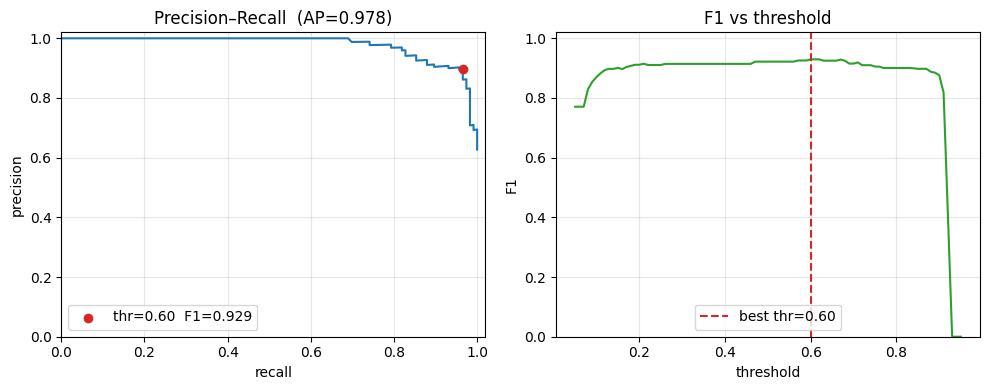

best threshold : 0.600   val F1 = 0.9295
vs 0.5 default :              val F1 = 0.9218  (Δ +0.0076)
✅ threshold + PR curve saved


In [31]:
# 0502
from smart_turn import evaluate_and_save_threshold

threshold_payload = evaluate_and_save_threshold(trainer, eval_dataset, CHECKPOINT_DIR)
print("✅ threshold + PR curve saved")

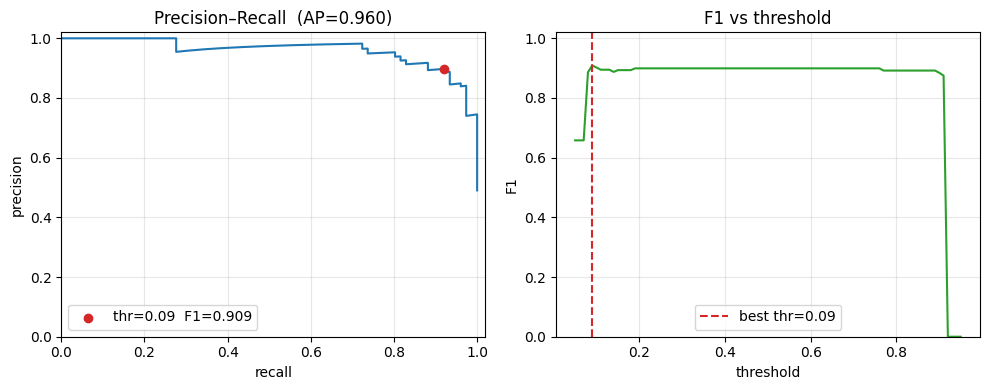

best threshold : 0.090   val F1 = 0.9091
vs 0.5 default :              val F1 = 0.8993  (Δ +0.0098)
✅ threshold + PR curve saved


In [7]:
# 0501
from smart_turn import evaluate_and_save_threshold

threshold_payload = evaluate_and_save_threshold(trainer, eval_dataset, CHECKPOINT_DIR)
print("✅ threshold + PR curve saved")

## Save

`03_compare.ipynb` and `04_export.ipynb` both reload from this path
with `SmartTurnModel.from_pretrained`. The feature extractor goes
alongside so inference doesn't have to re-derive the mel config.

In [8]:
model.save_pretrained(CHECKPOINT_DIR)
feature_extractor.save_pretrained(CHECKPOINT_DIR)
rel = CHECKPOINT_DIR.relative_to(CHECKPOINT_DIR.parent.parent)
print("saved :", rel)
print("files :", sorted(p.name for p in CHECKPOINT_DIR.iterdir() if p.is_file()))
print("✅ checkpoint saved")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved : smart-turn-zh-0501/baseline
files : ['config.json', 'model.safetensors', 'preprocessor_config.json', 'threshold.json']
✅ checkpoint saved


## Next

Once you've also run the other `02_<letter>_*` variants you want to
compare:

- `03_compare.ipynb` reloads every variant's checkpoint, scores them
  on `ds["test"]` at each one's shipped threshold, and emits a
  side-by-side metrics table + overlaid PR curves so you can pick a
  winner.
- `04_export.ipynb` then takes that single winner and produces FP32 +
  INT8 ONNX artifacts and a CPU latency benchmark.